# Análise exploratória dos títulos da Netflix

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [2]:
base = pd.read_csv("netflix_titles.csv")
base.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [3]:
base.shape

(8807, 12)

In [4]:
base.info()

<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8807 non-null   str  
 1   type          8807 non-null   str  
 2   title         8807 non-null   str  
 3   director      6173 non-null   str  
 4   cast          7982 non-null   str  
 5   country       7976 non-null   str  
 6   date_added    8797 non-null   str  
 7   release_year  8807 non-null   int64
 8   rating        8803 non-null   str  
 9   duration      8804 non-null   str  
 10  listed_in     8807 non-null   str  
 11  description   8807 non-null   str  
dtypes: int64(1), str(11)
memory usage: 825.8 KB


In [5]:
base.dtypes

show_id           str
type              str
title             str
director          str
cast              str
country           str
date_added        str
release_year    int64
rating            str
duration          str
listed_in         str
description       str
dtype: object

In [6]:
base.isna().sum()


show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [7]:
base.duplicated().sum()

np.int64(0)

In [8]:
base.value_counts().sum()
# São então 5332 registros sem valores nulos e 3475 rigistros com pelo menos algum valor nulo
# O value cont por padrão não contabiliza valores nulos

np.int64(5332)

In [9]:
base.isnull().any().sum()
# Quantas colunas possuem algum valor nulo

np.int64(6)

In [10]:
base.isnull().any(axis=1).sum()
# Quantos 

np.int64(3475)

In [11]:
base["release_year"].value_counts()


release_year
2018    1147
2017    1032
2019    1030
2020     953
2016     902
        ... 
1961       1
1959       1
1925       1
1966       1
1947       1
Name: count, Length: 74, dtype: int64

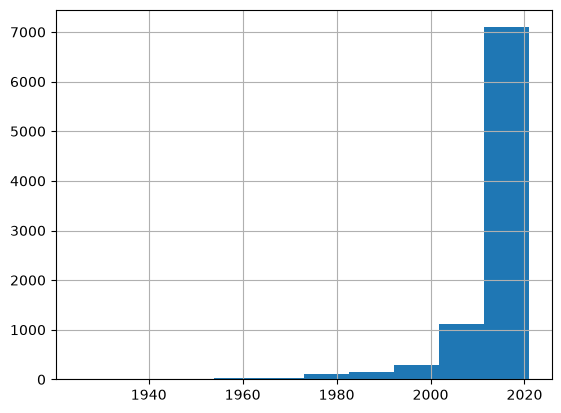

In [12]:

base["release_year"].hist()
plt.show()

## Observações iniciais

- A base possui 8.807 registros de filmes ou séries e 12 atributos.
- As colunas `director`, `cast`, `country`, `date_added`, `rating` e `duration` possuem valores ausentes.
- Há 5.332 registros completos e 3.475 registros com pelo menos um valor ausente.
- A maior parte das variáveis é categórica ou textual; `release_year` é numérica.
- Os anos de lançamento observados vão de 1925 a 2021.

## Próxima etapa: tratamento

O tratamento será definido coluna por coluna e precisa preservar a distinção entre dado ausente e dado conhecido. Não é adequado preencher `rating` automaticamente com a moda, pois isso inventaria uma classificação. Também não é adequado calcular uma média direta para `duration`, porque filmes usam minutos e séries usam temporadas. Primeiro serão validados os identificadores e títulos duplicados; depois, `duration` será separada por tipo de conteúdo e `date_added` será convertida para data, mantendo ausências explicitamente registradas.